## Binary Tree Concepts

### Basic Structure

- **Node** – a container holding a value/data and pointers/references to child nodes.
- **Root** – the topmost node of the tree; has no parent.
- **Edge** – the link connecting a parent node to a child node.
- **Leaf (external node)** – a node with no children.
- **Internal node** – a node with at least one child.
- **Parent / Child** – relative terms; a node pointing to another is its parent, the pointed-to node is its child.
- **Sibling** – nodes sharing the same parent.

### Binary Tree Specifics

- **Binary Tree** – a tree where each node has at most two children, conventionally called left and right.
- **Full Binary Tree** – every node has either 0 or 2 children (never exactly 1).
- **Complete Binary Tree** – all levels are fully filled except possibly the last, which is filled left to right.
- **Perfect Binary Tree** – all internal nodes have 2 children and all leaves are at the same depth.
- **Balanced Binary Tree** – the height difference between left and right subtrees of every node is small (often ≤1), keeping operations efficient. ∣height(node.left)−height(node.right)∣≤1
- **Degenerate (Pathological) Tree** – each parent has only one child, making it behave like a linked list.

### Measurements

- **Depth of a node** – number of edges from the root to that node.
- **Height of a node** – number of edges on the longest path from that node down to a leaf.
- **Height of a tree** – height of the root node.
- **Level** – all nodes at the same depth.

### Binary Search Tree (BST)

- **BST property** – for every node, left subtree values < node's value < right subtree values.
- **Successor/Predecessor** – the next larger/smaller value in sorted (in-order) sequence.

### Traversals

- **In-order** – Left → Node → Right (gives sorted order in a BST).
- **Pre-order** – Node → Left → Right (useful for copying trees).
- **Post-order** – Left → Right → Node (useful for deleting trees).
- **Level-order (BFS)** – visits nodes level by level using a queue.

### Other Key Terms

- **Subtree** – a tree formed by a node and all its descendants.
- **Ancestor / Descendant** – nodes on the path from root to a node (ancestors); nodes reachable downward from a node (descendants).
- **Traversal** – the process of visiting every node systematically.
- **Rotation** – restructuring operation (used in AVL/Red-Black trees) to maintain balance.

In order transversal are very important for Binary search tree, (draw it you'll see.)

In [1]:
# binary tree Node rep class

class TreeNode:
    def __init__(self, val, left= None, right= None):
        self.val = val
        self.left = left
        self.right = right

    def __str__(self):
        return str(self.val)

#### **Stack based DFS transversal of a Tree**

## Pre-order Traversal — My Rememberable Explanation

- We arrive at a Node → Pick its element (add it).
- Pre-order says: **After a Node, try to go LEFT.**
- We go LEFT and arrive at another Node → Pick its element (add it).
- Again, pre-order says: **After a Node, try to go LEFT.**
- We attempt to go LEFT:
  - If a Node exists → Go there, pick its element, and repeat.
  - If NO Node exists → Go back UP to the previous Node.
- We return to the previous Node and say: "Alright, we attempted LEFT, and there was nothing there."
- Pre-order says: **After LEFT, try RIGHT.**
- We go RIGHT and arrive at a Node → Pick its element (add it).
- Again, pre-order says: **After a Node, try to go LEFT.**
- We keep repeating this process until we've visited every Node.

---

### 🧠 Flash Card (Short Version)

**Pre-order = Node → Left → Right**

1. Arrive at a Node → **Pick it.**
2. Try going **LEFT**.
3. If LEFT doesn't exist → **Backtrack (go UP).**
4. Try going **RIGHT**.
5. Repeat for every Node.

**Memory trick:**
"Pick me first, then explore my Left, then my Right."

In [ ]:
# Pre-order traversal of a binary tree
# Node -> Left -> Right
def preorder(root):
    if not root:
        return []
    stack, result = [root], []
    while stack:
        node = stack.pop()
        result.append(node.val)
        # note we are keeping rights first in the stack because 
        # we would eventually visit all the right of left most subtrees before
        # visiting the right node in the right most subtrees.
        if node.right:
            stack.append(node.right)
        if node.left:
            stack.append(node.left)
    return result


In [3]:
root = TreeNode(1)

root.left = TreeNode(2)
root.right = TreeNode(3)

root.left.left = TreeNode(4)
root.left.right = TreeNode(5)

root.right.left = TreeNode(6)
root.right.right = TreeNode(7)

root.left.left.left = TreeNode(8)
root.left.left.right = TreeNode(9)

root.left.right.left = TreeNode(10)
root.left.right.right = TreeNode(11)

root.right.left.left = TreeNode(12)
root.right.left.right = TreeNode(13)

root.right.right.left = TreeNode(14)

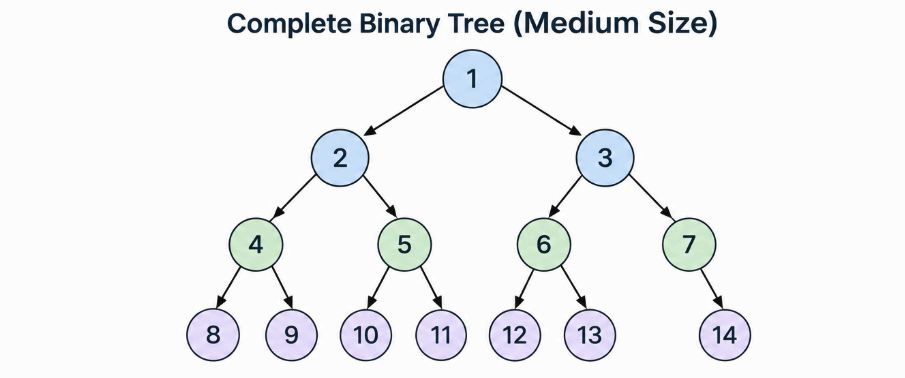

Note: 14 is to the left of 7, the diagram is wrong there...

In [9]:
pre_order = preorder(root)
print(pre_order)

[1, 2, 4, 8, 9, 5, 10, 11, 3, 6, 12, 13, 7, 14]



## In-order Traversal — My Rememberable Explanation

**In-order = Left → Node → Right**

- We arrive at a Node.
- In-order says: **Before picking a Node, try to go LEFT.**
- We go LEFT and arrive at another Node.
- Again, in-order says: **Try to go LEFT before picking the Node.**
- We keep going LEFT until we reach a point where there is NO Node.
- We backtrack (go UP) to the previous Node.
- In-order says: **Now pick the Node (add its element).**
- After picking the Node, in-order says: **Try to go RIGHT.**
- We go RIGHT:
  - If a Node exists → Arrive at it and try going LEFT again.
  - If NO Node exists → Backtrack to the previous Node.
- When we backtrack to a Node that has already been processed, we continue exploring its parent or its RIGHT subtree, depending on where we came from.
- We keep repeating this process until every Node has been visited.

---

### 🧠 Flash Card (Short Version)

**In-order = Left → Node → Right**

1. Arrive at a Node → **Try LEFT first.**
2. Keep going LEFT until there is no Node.
3. Backtrack → **Pick the Node.**
4. Try going RIGHT.
5. If RIGHT has a Node → Explore its LEFT subtree first.
6. If both subtrees are processed → Backtrack to the parent.
7. Repeat until every Node is processed.

**Memory trick:**
"Explore my LEFT, then pick ME, then explore my RIGHT."

In [ ]:
def Inoder(root):
    if not root:
        return []
    stack, result = [], []
    curr =  root
    while curr or stack:
        if curr:
            stack.append(curr) # push element to stack for revisiting   
            curr = curr.left # move left 
        else:
            # if there's no more left to go
            # last element in the stack if the leftmost we have visited
            node = stack.pop() # back track / go up
            result.append(node.val) # pick the node
            curr = node.right # go right, and we repeat. 
    return result


In [8]:
in_order = Inoder(root)
print(in_order)

[8, 4, 9, 2, 10, 5, 11, 1, 12, 6, 13, 3, 14, 7]


## Post-order Traversal — My Rememberable Explanation

**Post-order = Left → Right → Node**

- We arrive at a Node.
- Post-order says: **Before picking a Node, try to go LEFT.**
- We go LEFT and arrive at another Node.
- Again, post-order says: **Try to go LEFT before picking the Node.**
- We keep going LEFT until we reach a point where there is NO Node.
- We backtrack (go UP) to the previous Node.
- Post-order says: **Before picking the Node, check if it has a RIGHT subtree.**
- We check the RIGHT:
  - If a RIGHT Node exists → Go there and process its LEFT subtree first.
  - If NO RIGHT Node exists → **Pick the current Node (add its element).**
- After processing the RIGHT subtree, we backtrack to the parent.
- We check if the RIGHT subtree has already been processed:
  - If it has NOT been processed → Explore the RIGHT subtree.
  - If it HAS been processed → **Pick the parent Node (add its element).**
- We keep repeating this process until every Node has been visited and processed.

---

### 🧠 Flash Card (Short Version)

**Post-order = Left → Right → Node**

1. Arrive at a Node → **Try LEFT first.**
2. Keep going LEFT until there is no Node.
3. Backtrack → Check if RIGHT exists.
4. If RIGHT exists and hasn't been processed → **Explore RIGHT.**
5. If LEFT and RIGHT are processed → **Pick the NODE.**
6. Backtrack to the parent and repeat.
7. Continue until every Node is processed.

**Memory trick:**

"Explore my LEFT → Explore my RIGHT → Pick ME last."

---

### 🔑 Understanding `last_seen`

- `last_seen` remembers the last Node we completely processed.
- When we return to a parent, we check whether its RIGHT subtree has already been processed.
- If RIGHT has not been processed → Explore it.
- If RIGHT has already been processed → Process the parent.

**Remember:**

"Have I already processed my RIGHT? If yes, pick ME. If no, go RIGHT."

In [ ]:
def postorder_with_the_trick(root):
    if not root:
        return []
    stack, result = [root], []
    while stack:
        node =  stack.pop()
        result.append(node.val)
        if node.left:
            stack.append(node.left)
        if node.right:
            stack.append(node.right)
    return result[::-1]

def postorder_without_the_trick(root):
    stack, res = [], []
    if not root:
        return []
    curr, last_seen = root, None
    while stack or curr:
        if curr:
            stack.append(curr)
            curr = curr.left
        else:
            parent = stack[-1]
            if parent.right and parent.right != last_seen:
                curr = parent.right 
            else:
                res.append(parent.val)
                last_seen = stack.pop()
    return res


#### Level-order Traversal


In [ ]:
def levelOrderTrasversal(root):
    if not root:
        return []
    result = []
    from collections import deque
    queue = deque([root])
    while queue:
        node = queue.popleft()
        result.append(node.val)
        if node.left:
            queue.append(node.left)
        if node.right:
            queue.append(node.right)

    return result

## **N-arry Trees**

#### Pre-order trasvesal

Node -> Children

In [ ]:
class TreeNode:
    def __init__(self, val, children: list[TreeNode]=None):
        self.val = val
        self.children = children if children is not None else []

def PreOrderTraversalNaryTreeI(root):
    if not root:
        return []
    stack, result = [root], []
    while stack:
        node = stack.pop()
        result.append(node.val)
        for children in reversed(node.children):
            stack.append(children)
    return result

        

#### Post-order trasvesal

Children -> Node

In [ ]:
def PostOrderTraversalNaryTree(root):
    if not root:
        return []
    stack, result = [root], []
    while stack:
        node = stack.pop()
        result.append(node.val)
        for children in node.children:
            stack.append(children)
    return result[::-1]


#### Level-order trasvesal



In [ ]:
def LevelOrderTraversalNaryTree(root):
    result = []
    if not root:
        return []
    from collections import deque
    queue = deque([root])
    while queue:
        node = queue.popleft()
        result.append(node.val)
        for children in node.children:
            queue.append(children)
    return result


#### **Recursive based DFS transversal of a Tree**

In [ ]:
# node -> left -> right
def Preorder(root):
    def dfs(node):
        result = []
        if not node:
            # no node to process
            return result
        # process a node
        result.append(node.val)
        # go as left as possible
        result.extend(Preorder(node.left))
        # backtrack and go right....restart
        result.extend(Preorder(node.right))

        return result
    return dfs(root)


# In order: left -> node -> right
def Inorder(root):
    def dfs(node):
        result = []
        if not node:
            # no node to process
            return []
        # go as left as possible
        result.extend(Inorder(node.left))
        # add a node
        result.append(node.val)
        # backtrack and go right... restart
        result.extend(Inorder(node.right))

        return result
    return dfs(root)

# Post order: left -> right -> node
def Postorder(root):
    def dfs(node):
        result = []
        if not node:
            # no node to process
            return []
        # go as left as possible
        result.extend(Postorder(node.left))
        # back track and go as right as possible
        result.extend(Postorder(node.right))
        # add a node
        result.append(node.val)

        return result
    return dfs(root)

# Pre oder trasversal of N-ary tree node -> children (left to right )
def preOderNaryTree(root):
    def dfs(node):
        result = []
        if not node:
            return []
        result.append(node.val)
        for children in node.children:
            result.extend(preOderNaryTree(children))
        return result
    return dfs(root)

# Post Order trasversal: childreren -> node (left to right)
def postOrderNaryTree(root):
    def dfs(node):
        result = []
        if not node:
            return []
        for children in node.children:
            result.extend(postOrderNaryTree(children))
        # append after we have gotten to the childrens
        result.append(node.val)
        return result
    return dfs(root)

#### **Level order transversal**

In [ ]:
from collections import deque
# if we want each level as a list
def levelOrderTransversalBinaryTree(root):
    if not root:
        return []
    queue = deque([root])
    res = []
    while queue:
        qlen = len(queue)
        level = []
        for _ in range(qlen):
            node = queue.popleft()
            level.append(node.val)
            if node.left:
                queue.append(node.left)
            if node.right:
                queue.append(node.right)
        res.append(level)
    return res

# level order traversal using pre-order dfs
def  levelOrderTransversalBinaryTree(root):
    if not root:
        return []
    def getalllevels(node, level, levels):
        if not node:
            return#
        if level == len(levels):
            levels.append([])
        levels[level].append(node.val)
        if node.left:
            levels = getalllevels(node.left, level + 1, levels)
        if node.right:
            levels = getalllevels(node.right, level + 1, levels)
        return levels
        
    return getalllevels(root, 0, [])

# OR
def levelOrderTransversalBinaryTree():
    if not root:
        return []
    def getalllevels(node, level, levels):
        if not node:
            return
        if level not in levels:
            levels[level] = []
        levels[level].append(node.val)
        if node.left:
            levels = getalllevels(node.left, level + 1, levels)
        if node.right:
            levels = getalllevels(node.right, level + 1, levels)
        return levels
    return list(getalllevels(root, 0, {}).values())

# for N-ary
def levelOrderTransversalNaryTree(root):
    if not root:
        return []
    result = []
    from collections import deque
    queue = deque([root])
    while queue:
        qlen =  len(queue)
        level = []
        for _ in range(qlen):
            node =  queue.popleft()
            level.append(node.val)
            for children in node.children:
                queue.append(children)
        result.append(level)
    return result

# level order traversal using preorder dfs
def levelOrderTransversalNaryTree(root):
    if not root:
        return []
    def getalllevels(node, level, levels):
        levels = []
        if not node:
            return
        if len(levels) == level:
            levels.append([])
        levels[level].append(node.val)
        for child in node.children:
            levels = getalllevels(child, level + 1, levels)
        return levels
    return getalllevels(root, 0, [])

# OR
def levelOrderTransversalNaryTree(root):
    if not root:
        return []
    def getalllevels(node, level, levels):
        if not node:
            return 
        if level not in levels:
            levels[level] = []
        levels[level].append(node.val)
        for child in node.children:
            levels = getalllevels(child, level + 1, levels)
        return levels
    return getalllevels(root, 0, {})

#### Pre-Order, In-Order and Post-Order In one trasversal


we will use a state machine to process the node
we know that for every node, they are added on "node" in the trasversal orders, i.e:
pre-order: "node" -> left -> right
in-order: left -> "node" -> right
post-order: left-> right -> "node"

so in order to get the preorder, inorder and postorder positions of a node... we will need to mark a node with three states

state 0: when we arrive at a node for the first time - this is exactly what happens in pre-order
state 1: when we arrive at a node coming from it's left child - this is exactly what happens in in-order
state 2: when we arrive at a node coming from it's right child - this is exactly what happens in post-order 

To make effective use of this states
when we process a node for the first time (node: state 0 ), we want to add the node back to the stack in state 1 before adding the node.left in state 0 to the stack. This is so that when we pop the node.left from the stack and process it we then know that the node in state 1 behind it will be processed right after the node.left (going left ->node (in-order))

In [ ]:
def PreInAndPostOrderTRasversal(root):
    pre, ino, post = [], [], []
    if not root:
        return pre, ino, post
    stack = [(root, 0)]
    while stack:
        node, state = stack.pop()
        if state == 0:
            pre.append(node.val)
            stack.append((node, 1))
            if node.left:
                stack.append((node.left, 0))
        elif state == 1:
            ino.append(node.val)
            stack.append((node, 2))
            if node.right:
                stack.append((node.right, 0))
        else:
            post.append(node.val)
    return pre, ino, post


#### **Max Depth of a binary tree**

In [ ]:
# provided a depth of node is the number of edges from the node to the root
def maxDepth(root):
    max_depth = 0
    if not root:
        return max_depth
    
    def dfs(node, curr_depth):
        nonlocal max_depth
        if not node:
            max_depth = max(max_depth, curr_depth) # maximize if we finish one path
            return
        # max_depth = max(max_depth, curr_depth): you could also put it hear. This maximizes as we progress the path
        dfs(node.left, curr_depth + 1)
        dfs(node.right, curr_depth + 1)
    dfs(root, 0) # if the depth of a node is the number of node from the node to root we will start max depth at 1 for the root (that is, counting it) dfs(root, 1)
    
    return max_depth

# Another way to write it:
def maxDepth(root):
    max_depth = 0
    if not root:
        return 0
    def dfs(node, curr_depth):
        nonlocal max_depth
        # if I reach the end of a path, maximize the depth
        if not node.left and not node.right:
            max_depth = max(max_depth, curr_depth)
            # terminate path search since we reached the end
            return
        if node.left:
            dfs(node.left, curr_depth + 1)
        if node.right:
            dfs(node.right, curr_depth + 1)
    dfs(root)
    return max_depth

# A more pythonic way to do this

def maxDepth(root):
    if not root:
        return 0
    def dfs(node):
        if not node:
            return 0
        leftheight = dfs(node.left)
        rightheight = dfs(node.right)
        return 1 + (max(leftheight, rightheight))
    return dfs(root) - 1 


# provided a depth of node is the number of nodes from the node to the root
def maxDepth(root):
    max_depth = 0
    if not root:
        return max_depth
    
    def dfs(node, curr_depth):
        nonlocal max_depth
        if not node:
            return
        max_depth = max(max_depth, curr_depth)
        dfs(node.left, curr_depth + 1)
        dfs(node.right, curr_depth + 1)
    dfs(root, 1) # if the depth of a node is the number of node from the node to root we will start max depth at 1 for the root (that is, counting it) dfs(root, 1)
    
    return max_depth

# A more pythonic way to do this

def maxDepth(root):
    if not root:
        return 0
    def dfs(node):
        if not node:
            return 0
        leftheight = dfs(node.left)
        rightheight = dfs(node.right)
        return 1 + (max(leftheight, rightheight))
    return dfs(root) 

#### **Min Depth of Binary tree**

In [ ]:
def minDepth(root):
    if not root:
        return 0
    min_depth = float("inf")
    def dfs(node, curr_depth):
        nonlocal min_depth
        if not node.left and not node.right:
            min_depth = min(min_depth, curr_depth)
        if node.left:
            dfs(node.left, curr_depth + 1)
        if node.right:
            dfs(node.right, curr_depth + 1)
    dfs(root, 0)
    return min_depth

#### **Max Depth of a N-ary tree / height of an N-ary tree (not a node in the tree)**

In [ ]:
def maxDepth(root):
    if not root:
        return 0
    max_depth = 0
    def dfs(node, curr_height):
        nonlocal max_depth
        if not node:
            return 
        # go down the child
        max_depth =  max(max_depth, curr_height)
        for child in node.children:
            dfs(child, curr_height + 1)
    dfs(root, 0)
    return max_depth

#### **Min depth of a N-ary tree**

#### **Check for a balanced binary tree**

In [ ]:
def Balanced(root):
    if not root:
        return True
    """
    For a balanced binary tree we know ther height difference of subtrees are <= 1, i.e.
    |height(node.left) - height(node.right)| <= 1 for every node.
    """
    def height(node):
        height = 0
        def dfs(node, curr_height):
            nonlocal height
            if not node:
                return height
            height = max(height, curr_height)
            dfs(node.left, curr_height + 1)
            dfs(node.right, curr_height + 1)
        dfs(node, 0)
        return height


    
    def checkNodesubtree(node):
        if not node:
            return True
        if abs(height(node.left) - height(node.right)) >  1:
            return False        
        return checkNodesubtree(node.left) and checkNodesubtree(node.right)
    return checkNodesubtree(root) #this is O(N^2)


# How to do this is O(N)
def Balanced(root):
    """
    To archive O(N) TC we need to be able to merge the exploration and the 
    height/max depth calculation and the validation together into one pass

    One popular trick is to return the height of a node if its subtree is balanced
    and return -1 other wise... 

    since we want to get the height of left node and right node and compare then
    |height(node.left) - height(node.right)| >= 1
    then that subtree is valid...
    we know this is a post-oder trasversal: calc left first, then right, then process node
    by comparing left and right together.

    we want to check that the whole tree is valid: that is we should end up with the height of root
    and not -1.

    at any point iof the height of the right node and height from the left node doesn't satify balance tree condition
    that node result is -1 and we can check if any node resulted in -1 we can throw false immediately meaning it subtree
    wasn't balanced making the whole tree inbalanced.
    """
    def check(node):
        if not node:
            # return the height at that point
            return 0
        # go left
        leftheight = check(node.left)
        # if this node subtree isn't balance don't do uneccessary work, 
        # just make the rest of the nodes upward till root return -1
        if leftheight == -1:
            return -1
        rightheight = check(node.right)
        if rightheight == -1:
            return -1
        if abs(leftheight - rightheight) > 1:
            return -1
        return 1 + max(leftheight, rightheight)
    return check(root) != -1

#### **Diameter of a Binary Tree**

In [ ]:
# O(n^2)
def Diameter(root):
    diameter = 0
    def height(node):
        max_depth = 0
        def dfs(node, curr_height):
            nonlocal max_depth
            if not node:
                return
            # move left
            max_depth =  max(max_depth, curr_height)
            dfs(node.left, curr_height + 1)
            dfs(node.right, curr_height + 1)
        dfs(node, 0)
        return max_depth
    def calcNodeDiameter(node):
        nonlocal diameter
        if not node:
            return
        # add one because we are skipping the edge between Node and
        # left or right as we calculate height for left and height 
        # don't add the 1 if left and right result in None respectively
        leftheight = 1 + height(node.left) if node.left else 0
        rightheight = 1 + height(node.right) if node.right else 0
        diameter = max(diameter, leftheight + rightheight)
        calcNodeDiameter(node.left)
        calcNodeDiameter(node.right)
    calcNodeDiameter(root)
    return diameter

# O(N) approach:

def Diameter(root):
    diameter = 0
    def dfs(node):
        nonlocal diameter
        if not node:
            return 0 
        leftheight = dfs(node.left)
        rightheight = dfs(node.right)
        diameter = max(diameter, leftheight + rightheight)
        return 1 + max(leftheight, rightheight)
    dfs(root)
    return diameter

#### **Diameter of N-ary tree**

#### **Maximum Path Sum in Binary Tree (Return Path)**

#### **Maximum Path Sum in Binary Tree (Return Sum)**

#### **Minimum Path sum in Binary Tree (return Path)**

#### **Minimum Path sum in Binary three (resturn Sum)**

#### **Maximum Path Sum in N-ary Tree (Return Path)**

#### **Maximum Path Sum in Binary Tree (Return Sum)**

#### **Minimum Path Sum in N-ary Tree (Return the Path)**

#### **Minimum Path Sum in N-ary Tree (Return the sum)**

#### **Check if two trees are identical**

#### **Zig Zag traversal of a tree**

#### **Boundary Traversal of a binary Tree**

#### **Vertical order transversal**

#### **Vertical order transversal II**

#### **Top view of Binary tree**

#### **Top view of N-ary Tree**

#### **Bottom view of Binary Tree**

#### **Bottom view of N-arry Tree**

#### **Right and Left View of Binary Tree**

#### **Right and Left View of N-ary Tree**

#### **Check for symmetrical Binary Tree**

#### **Check for symmetrical N-ary Tree**

#### **Print all path in a Binary Tree**

#### **Print all path in an N-ary Tree**

#### **LCA in a Binary Tree**

#### **LCA in N-ary Tree**

#### **Validate binary search tree**

In [5]:
"""    root
 -inf   8    +inf
       / \
      4   10
     / \    \
    2   6    12
   / \ / \   /
  1  3 5 7  9
 
"""

def isValidBST(root):
    def isValidNode(node, min_left, min_right):
        if not node:
            return True
        if not (min_left < node.val < min_right):
            return False
        return (
            isValidNode(node.left, min_left, node.val) and
            isValidNode(node.right, node.val, min_right)
        )
    
    return isValidNode(root, float('-inf'), float('inf'))

<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_67197/2622345203.py:5: SyntaxWarning: invalid escape sequence '\ '
  / \    \


#### **Binary Tree right side view**

In [ ]:
from collections import deque
def BinaryTreeRightSideView(root):
    if not root:
        return []
    # perform bfs
    queue = deque([root])
    res = []
    while queue:
        qlen = len(queue)
        for i in range(qlen):
            node = queue.popleft()
            if node.left:
                queue.append(node.left)
            if node.right:
                queue.append(node.right)
            if i == qlen - 1:
                res.append(node.val)
    return res

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right

# Path sum I
class Solution:
    def hasPathSum(self, root, targetSum: int) -> bool:
        if not root:
            return False
        
        def dfs(node, curr_sum):

            if not node:
                False

            curr_sum += node.val

            if not node.left and not node.right:
                return curr_sum == targetSum

            return dfs(node.left, curr_sum) or dfs(node.right, curr_sum)
        return dfs(root, 0)



#### **Path sum II**

return every paths with a sum k

In [ ]:
def PathSum(root, targetSum):
    if not root:
        return []
    res = []
    def dfs(node, curr_sum, curr_path):
        if not node:
            return
        
        new_sum = curr_sum + node.val
        new_path = curr_path + [node.val]

        if not node.left and not node.right and new_sum == targetSum:
            res.append(new_path)
        
    dfs(root, 0, [])
    return res



In [3]:
def PathSum(root, targetSum):
    if not root:
        return []
    
    res = []
    
    def dfs(node, curr_sum, curr_path):
        if not node:
            return
        
        curr_sum += node.val
        curr_path.append(node.val)
        if not node.left and not node.right and curr_sum ==  targetSum:
            res.append(curr_path[:])
        
        dfs(node.left, curr_sum, curr_path)
        dfs(node.right, curr_sum, curr_path)
        curr_path.pop()
    dfs(root, 0, [])
    return res

In [5]:
class Solution:
    def smallestFromLeaf(self, root) -> str:
        self.res = None
        
        def dfs(node, path):
            if not node:
                return
            
            # Add current character
            path = chr(node.val + ord('a')) + path  # Prepend to build leaf-to-root
            
            # If leaf node, update result
            if not node.left and not node.right:
                if self.res is None or path < self.res:
                    self.res = path
                return
            
            dfs(node.left, path)
            dfs(node.right, path)
        
        dfs(root, "")
        return self.res

#### **Height of a binary Tree**

In [ ]:
def Height(root):
    
    if not root:
        return 0

    left = Height(root.left)
    right = Height(root.right)

    return  1 + max(left, right )

#### **Max depth of a binary Tree**

#### **Diameter of a Binary Tree**

#### **Least Common ancestors**

#### **Diameter of a Binary tree**

#### **Check if two trees are identical or not**

#### **Top Veiw of a binary Tree**

#### **Bottom view of a binary Tree**

#### **Check for symmetrical Binary Trees**

#### **Maximum width of a binary tree**

#### **Serialize and Deserialize a binary Tree**

#### **Morris Transversal**

#### **Flatten a BInary Tree to a linkedlist**

#### **Search in a binary search tree**

#### **FLoor and Ceil in a Binary search tree**

##### **Insert and Delete Node in a Binary Search Tree**

#### **Kth Smallest/largest Element in a BST**

#### **Lowest Common Ancestor of a BST**

#### **InOrder and preOrder successor in BST**

#### **BST Iterator**

#### **Two sum in BST**

#### **Recover BST** 

#### **Largest BST in Binary Tree**